Created by Justin Cooke 02/11/2026

The purpose of this script is to investigate the influence of spatial area on the common mode, with implications for variance.

Comparison of variance between HYCOM in the region of 22N to 28N and 83W to 90W vs in the CPIES region of 25 to 27.5N and 86W to 89W revealed the CPIES Variance to be 2.5x less than that in the HYCOM, despite having higher EKE.

In [ ]:
# Import modules

# Sci computing
import numpy as np
import scipy as sp
import seawater as sw
import scipy.sparse.linalg as sla
from contourpy import contour_generator
import pyfftw 

# Importing bathymetry (tiff)
import rasterio as geo

# Parallel comupting
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar

# For Data
import netCDF4 as nc
import xarray as xr

# Plotting stuff
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grdspc
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
import cmocean as cm

# Gen stuff
from datetime import date
today = date.today()

In [101]:
# Low Pass Filter

from scipy.signal import butter, filtfilt

def lowpassfilt(data, filtT, sampT):
    """
    Low-pass filter a 1D data vector using a second-order Butterworth filter.
    Filtering is applied forward and backward to eliminate phase shift.

    Parameters
    ----------
    data : array_like
        Input data vector (1D array). Can be row or column oriented.
    filtT : float
        Filter period (same units as sampT).
    sampT : float
        Sampling period (same units as filtT).

    Returns
    -------
    out : ndarray
        Filtered data vector, same shape as input.
    """

    data = np.asarray(data)
    if data.ndim != 1:
        raise ValueError("Input must be a 1D vector, not an array.")

    # Check if input was a row vector (for shape preservation)
    was_row = data.ndim == 1 and data.shape[0] < data.shape[-1]

    # Remove linear trend between endpoints
    n = len(data)
    x = np.arange(1, n + 1)
    p = np.polyfit([1, n], [data[0], data[-1]], 1)
    lineartrend = np.polyval(p, x)
    detrended = data - lineartrend

    # Check for NaNs
    if np.isnan(detrended).any():
        raise ValueError("Data contains NaNs; remove them before filtering.")

    # Butterworth filter setup
    # Wn is the normalized cutoff frequency (Nyquist = 0.5 / sampT)
    Wn = (2.0 / filtT) * sampT
    if Wn >= 1:
        raise ValueError("Cutoff frequency too high; ensure filtT > 2 * sampT.")
    b, a = butter(2, Wn)

    # Zero-phase filtering
    filtered = filtfilt(b, a, detrended)

    # Add linear trend back
    out = filtered + lineartrend

    # Preserve input orientation
    if was_row:
        out = out.reshape(1, -1)
    else:
        out = out.reshape(-1)

    return out


# Band-pass filter

def butterfilt_bandpass(x, order, filtThi, filtTlo, sampT):
    """
    Band-pass Butterworth filter with zero-phase (forward–reverse) filtering.

    Parameters
    ----------
    x : array_like
        Input vector (row or column). Will be returned in the same orientation.
    order : int
        Order of the Butterworth filter.
    filtThi : float
        Longer period of the band (high cutoff).
    filtTlo : float
        Shorter period of the band (low cutoff).
    sampT : float
        Sampling period. Must have same units as filtThi/filtTlo.

    Returns
    -------
    out : ndarray
        Filtered data vector, same shape (row/column) as input.
    """

    x = np.asarray(x)

    # Ensure input is 1-D vector
    if x.ndim != 1 and not (x.ndim == 2 and 1 in x.shape):
        raise ValueError("Input must be a vector, not an array.")

    # Preserve original orientation
    transpose_back = False
    if x.ndim == 2:
        if x.shape[0] == 1:  # row vector
            x = x.flatten()
            transpose_back = True
        elif x.shape[1] == 1:  # column vector
            x = x.flatten()
        else:
            raise ValueError("Input must be a vector, not a matrix.")

    n = x.size

    # Trend removal (linear ramp)
    t = np.arange(1, n + 1)
    P = np.polyfit([1, n], [x[0], x[-1]], 1)
    linear_trend = np.polyval(P, t)
    x_detrended = x - linear_trend

    # Normalized band edges (MATLAB: Wnlo = (2/filtTlo)*sampT)
    Wnlo = (2.0 / filtTlo) * sampT  # upper normalized cutoff
    Wnhi = (2.0 / filtThi) * sampT  # lower normalized cutoff
    Wn = [Wnhi, Wnlo]

    # Create Butterworth filter
    b, a = butter(order, Wn, btype='bandpass')

    # NaN check
    if np.isnan(x_detrended).any():
        raise ValueError("NaNs present in input data. Remove them before filtering.")

    # Zero-phase filtering
    out = filtfilt(b, a, x_detrended)

    # MATLAB code *comments out* adding the trend back:
    # out = out + linear_trend
    # For direct equivalence, we keep it commented.
    
    # Reshape to original orientation
    if transpose_back:
        out = out[np.newaxis, :]

    return out

In [ ]:
# For plotting; have the bathymetry of the gulf

ds_gulf = geo.open('/home/justin_cooke_uri_edu/DeepCyclones/gulf.tiff')
#ds_gulf = geo.open('../gulf.tiff')
img = ds_gulf.read(1)

(gm,gn) = np.shape(img)
gulf_lon = np.linspace(-90,-82,gn)
gulf_lat = np.linspace(22,28,gm)

# To get the aspect ratio right
ymid = np.mean(gulf_lat)
ymid_rad = ymid*np.pi/180

# For plotting: labels

lon_xticks = np.array((-90,-89,-88,-87,-86,-85,-84,-83))
lon_xticklbls = ['$90^\circ$W','$89^\circ$W','$88^\circ$W','$87^\circ$W','$86^\circ$W','$85^\circ$W','$84^\circ$W','$83^\circ$W']

lat_yticks = np.array((22,23,24,25,26,27,28))
lat_yticklbls = ['$22^\circ$N','$23^\circ$N','$24^\circ$N','$25^\circ$N','$26^\circ$N','$27^\circ$N','$28^\circ$N']

In [3]:
ds_eref = xr.open_mfdataset('./hycom_data/CommonMode/hycom_etaref_*.nc',combine='nested',concat_dim='MT')
ds_ssh = xr.load_dataset('./hycom_data/hycom_ssh_filtered.nc')

In [6]:
# Load the variables we care about
eref_wCM = ds_eref['eta_ref_wCommonMode']
ssh = ds_ssh['ssh']


lon = ds_eref['Longitude']
lat = ds_eref['Latitude']

Nt,Nlat,Nlon = eref_wCM.shape

In [112]:
# Create a smaller eref_wCM but in the cpies region only

# Create a bounding box
dsc_minlat = lat.values[81]
dsc_maxlat = lat.values[-15]

dsc_minlon = lon.values[25]
dsc_maxlon = lon.values[100]

print(f'Bounded by {dsc_minlat}N to {dsc_maxlat}N and {dsc_minlon}W to {dsc_maxlon}W')

# Select the values within the DSC bounding box and then avg them spatially
cpies_eref = eref_wCM.sel(Latitude=slice(dsc_minlat,dsc_maxlat),Longitude=slice(dsc_minlon,dsc_maxlon))
Nt_cpies,Nlat_cpies,Nlon_cpies = cpies_eref.shape

cpies_lon = lon.values[25:101]
cpies_lat = lat.values[81:-14]

Bounded by 25.006114959716797N to 27.51681137084961N and -89.0W to -86.0W


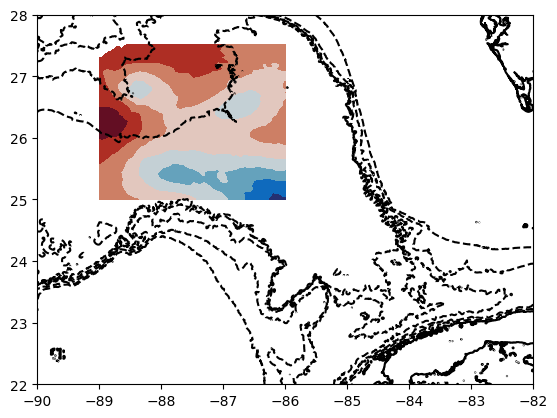

In [109]:
plt.contourf(cpies_lon,cpies_lat,cpies_eref[0,:,:],cmap=cm.cm.balance)
plt.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black')

In [41]:
eref_noCM = eref_wCM - xr.DataArray.mean(eref_wCM,dim=["Latitude","Longitude"],skipna=True)
cpies_eref_noCM = cpies_eref - xr.DataArray.mean(cpies_eref,dim=["Latitude","Longitude"],skipna=True)

In [43]:
big_CM = xr.DataArray.mean(eref_wCM,dim=["Latitude","Longitude"],skipna=True)
small_CM = xr.DataArray.mean(cpies_eref,dim=["Latitude","Longitude"],skipna=True)

(-1.85, -1.65)

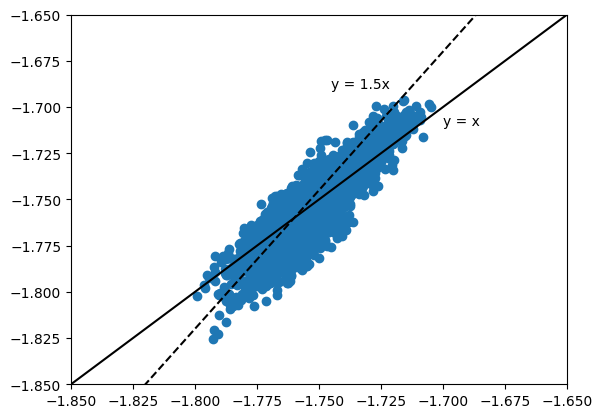

In [ ]:
xx = np.linspace(-10,10,100)
yy = 1.5*xx

plt.plot(big_CM.values,small_CM.values,marker='o',linestyle='none')
plt.plot(xx,xx,color='black',linestyle='-')
plt.plot(xx,yy+0.88,color='black',linestyle='--')
plt.text(-1.7,-1.71,'y = x')
plt.text(-1.745,-1.69,'y = 1.5x')
plt.xlim(-1.85,-1.65)
plt.ylim(-1.85,-1.65)

<>:60: SyntaxWarning: invalid escape sequence '\e'
<>:78: SyntaxWarning: invalid escape sequence '\e'
<>:60: SyntaxWarning: invalid escape sequence '\e'
<>:78: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1626145/3421223214.py:60: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
/tmp/ipykernel_1626145/3421223214.py:78: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
/tmp/ipykernel_1626145/3421223214.py:59: RuntimeWarning: Degrees of freedom <= 0 for slice.
  cb = ax.contourf(lon,lat,np.nanvar(eref_noCM_vals_bp,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
/tmp/ipykernel_1626145/3421223214.py:77: RuntimeWarning: Degrees of freedom <= 0 for slice.
  cb = ax.contourf(cpies_lon,cpies_lat,np.nanvar(cpies_eref_noCM_vals_bp,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.00025,11),extend='max')


Text(0.5, 1.0, '150-60 Days')

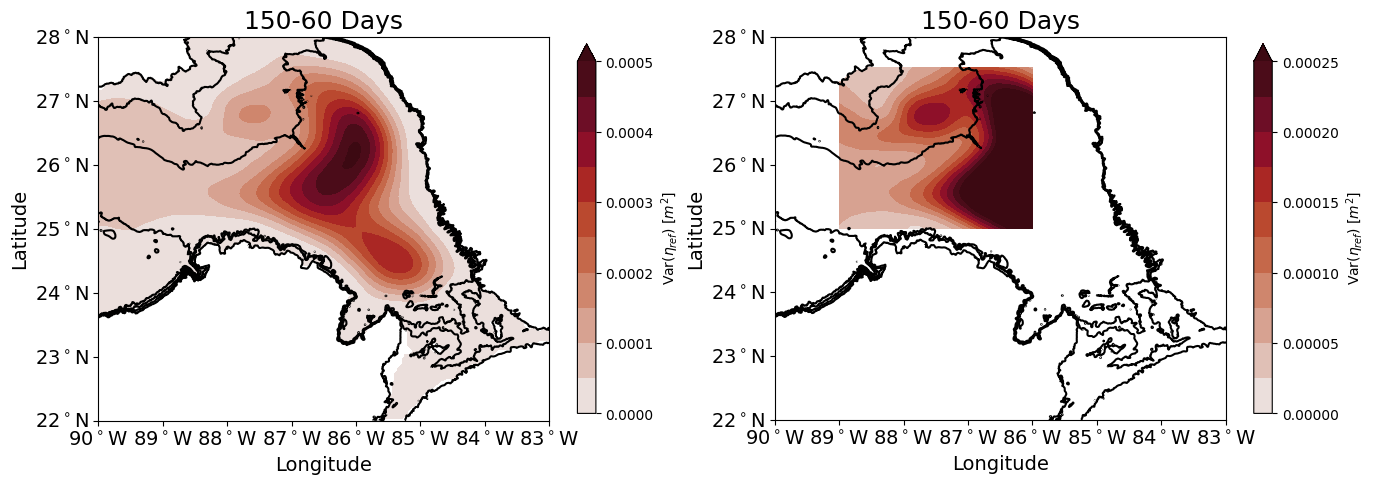

In [121]:
# Create the D Matrix

# Get eta ref values
eref_noCM_vals = eref_noCM.values
cpies_eref_noCM_vals = cpies_eref_noCM.values

# Create a mask containing all the points that are not NaNs
mask = ~np.isnan(eref_noCM_vals[0,:,:])
idx = np.where(mask)
mask_2 = ~np.isnan(cpies_eref_noCM_vals[0,:,:])
idx_2 = np.where(mask_2)

# Create D
D = eref_noCM_vals[:,idx[0],idx[1]]
D = np.moveaxis(D,0,1)
D_2 = cpies_eref_noCM_vals[:,idx_2[0],idx_2[1]]
D_2 = np.moveaxis(D_2,0,1)

bp_D = np.empty_like(D)
bp_D_2 = np.empty_like(D_2)

filtThi = 150.0
filtTlo = 60.0

fc = 10.0
sc = 1.0

for i in range(D.shape[0]):
    bp_D[i,:] = butterfilt_bandpass(D[i,:],2,filtThi,filtTlo,sc)
for i in range(D_2.shape[0]):
    bp_D_2[i,:] = butterfilt_bandpass(D_2[i,:],2,filtThi,filtTlo,sc)

eref_noCM_vals_bp = np.full((Nt,Nlat,Nlon),np.nan)
cpies_eref_noCM_vals_bp = np.full((Nt,Nlat_cpies,Nlon_cpies),np.nan)

for t in range(Nt):
    cpies_eref_noCM_vals_bp[t,idx_2[0],idx_2[1]] = bp_D_2[:,t]
    eref_noCM_vals_bp[t,idx[0],idx[1]] = bp_D[:,t]

cpies_eref_noCM_bp = xr.DataArray(
    cpies_eref_noCM_vals_bp,
    coords=cpies_eref_noCM.coords,
    dims=cpies_eref_noCM.dims,
    name='cpies_eref_noCM_bp'
)

eref_bp = xr.DataArray(
    eref_noCM_vals_bp,
    coords=eref_noCM.coords,
    dims=eref_noCM.dims,
    name='eref_noCM_bp'
)
# Plot mean and variance of everything

fig = plt.subplots(1,2,figsize=(16,8))

ax = plt.subplot(1,2,1)
#cb = ax.contourf(lon,lat,eref_18yr_mean,cmap=cm.cm.balance,levels=np.linspace(-0.04,0.04,11),extend='both')
cb = ax.contourf(lon,lat,np.nanvar(eref_noCM_vals_bp,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
#plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m$]')#,location='bottom')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
#ax.set_title('18-year Variance of $\eta_{ref}$',fontsize=18)
ax.set_title(f'{int(filtThi)}-{int(filtTlo)} Days',fontsize=18)

ax = plt.subplot(1,2,2)
#cb = ax.contourf(lon,lat,eref_18yr_mean,cmap=cm.cm.balance,levels=np.linspace(-0.04,0.04,11),extend='both')
cb = ax.contourf(cpies_lon,cpies_lat,np.nanvar(cpies_eref_noCM_vals_bp,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.00025,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
#plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m$]')#,location='bottom')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
#ax.set_title('18-year Variance of $\eta_{ref}$',fontsize=18)
ax.set_title(f'{int(filtThi)}-{int(filtTlo)} Days',fontsize=18)



#fig.savefig(f'./Figures/BP_{int(filtThi)}to{int(filtTlo)}_var_ampcolor_{today}.svg',format='svg')
#fig.savefig(f'./Figures/LP_{fc}_18yr_var_ampcolor_{today}.svg',format='svg')